# Notebook 03 — O Nordeste e suas Contradições

**Projeto:** Mapa da Inseminação Artificial no Brasil  
**Autor:** Mateus Martins — Médico Veterinário

O Nordeste pecuário me intriga. Tem 30 milhões de bovinos, mas a adoção de IA 
vai de 79,5% (Alagoas) a 5,2% (Piauí). Neste notebook investigo por que 
Alagoas é outlier, qual o potencial do MATOPIBA, quais as barreiras reais
e quanto dinheiro está sendo deixado na mesa.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
AZUL = '#2E75B6'
VERDE = '#548235'
VERMELHO = '#C0504D'
AMARELO = '#E6A817'
CINZA = '#7F7F7F'
LARANJA = '#ED7D31'
plt.rcParams['figure.dpi'] = 150

df = pd.read_csv('data/processed/dataset_ia_brasil.csv')
asbia_brasil = pd.read_csv('data/raw/asbia_dados_compilados.csv')

ne_states = ['MA', 'PI', 'CE', 'RN', 'PB', 'PE', 'AL', 'SE', 'BA']
df_ne = df[df['sigla_uf'].isin(ne_states)].copy()

print(f'Nordeste: {len(df_ne)} estados')
print(f'Rebanho total NE: {df_ne["rebanho"].sum()/1e6:.1f}M cabeças')
print(f'Fêmeas estimadas NE: {df_ne["femeas_estimadas"].sum()/1e6:.1f}M')

Nordeste: 9 estados
Rebanho total NE: 32.8M cabeças
Fêmeas estimadas NE: 18.0M


## 1. Por que Alagoas é Outlier?

Alagoas com 79,5% de fêmeas inseminadas (corte) é o dado mais contraintuitivo
deste estudo. É o segundo lugar nacional, atrás apenas de Santa Catarina.
Um estado pequeno, do Nordeste, batendo todo o Centro-Oeste.

Vamos investigar os possíveis motivos.

Comparação: Alagoas vs estados vizinhos
BA: Rebanho 12.1M | Corte 18.5% | Leite 6.5%
PE: Rebanho 2.4M | Corte 12.5% | Leite 7.0%
AL: Rebanho 1.4M | Corte 79.5% | Leite 8.5%
SE: Rebanho 1.3M | Corte 15.8% | Leite 5.0%


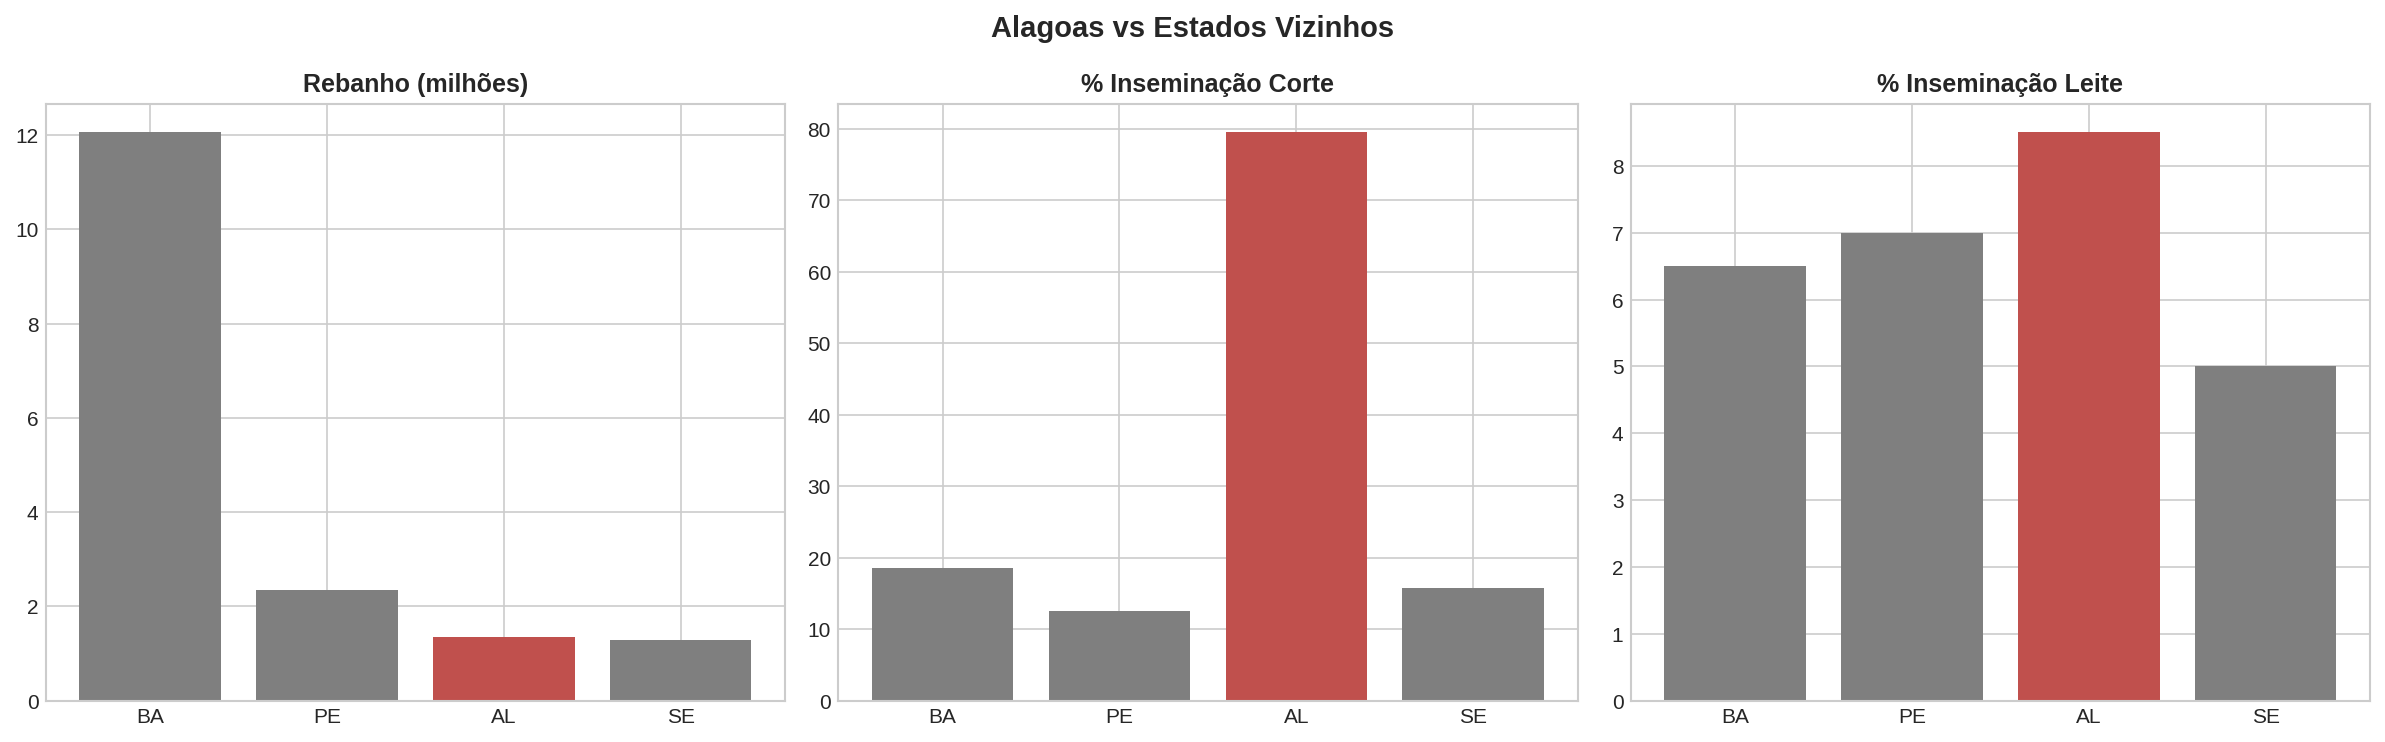

In [2]:
# Comparação AL vs vizinhos
vizinhos = ['AL', 'SE', 'PE', 'BA']
df_viz = df[df['sigla_uf'].isin(vizinhos)].copy()

print('Comparação: Alagoas vs estados vizinhos')
print('='*60)
for _, row in df_viz.iterrows():
    print(f"{row['sigla_uf']}: Rebanho {row['rebanho']/1e6:.1f}M | "
          f"Corte {row['pct_femeas_inseminadas_corte']:.1f}% | "
          f"Leite {row['pct_femeas_inseminadas_leite']:.1f}%")

# Visualização
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Rebanho
axes[0].bar(df_viz['sigla_uf'], df_viz['rebanho']/1e6, color=[VERMELHO if uf == 'AL' else CINZA for uf in df_viz['sigla_uf']])
axes[0].set_title('Rebanho (milhões)', fontweight='bold')

# % Inseminação corte
axes[1].bar(df_viz['sigla_uf'], df_viz['pct_femeas_inseminadas_corte'], 
            color=[VERMELHO if uf == 'AL' else CINZA for uf in df_viz['sigla_uf']])
axes[1].set_title('% Inseminação Corte', fontweight='bold')

# % Inseminação leite
axes[2].bar(df_viz['sigla_uf'], df_viz['pct_femeas_inseminadas_leite'],
            color=[VERMELHO if uf == 'AL' else CINZA for uf in df_viz['sigla_uf']])
axes[2].set_title('% Inseminação Leite', fontweight='bold')

fig.suptitle('Alagoas vs Estados Vizinhos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Hipóteses para o caso Alagoas

1. **Rebanho pequeno** (~1,35M cabeças): mais fácil atingir % alta. Uma central de 
   inseminação cobre uma proporção grande do rebanho.

2. **Programas estaduais de incentivo**: AL teve programas de melhoria genética do 
   rebanho leiteiro com subsídio para inseminação.

3. **Proximidade de centrais de sêmen**: PE, SE e BA têm centrais da CRV, Alta 
   Genetics e ABS que atendem AL.

4. **Perfil do rebanho**: alta proporção de gado leiteiro/dupla aptidão 
   (Girolando), que historicamente usa mais IA que gado estritamente de corte.

5. **Fator escala**: quando o denominador é pequeno, poucos programas de IA 
   conseguem mover o percentual significativamente.

**Nota de cautela**: o dado de 79,5% pode refletir em parte a metodologia do 
INDEX ASBIA — se as vendas de sêmen no estado são altas relativas ao rebanho, 
o % calculado sobe. Não significa necessariamente que 79,5% das vacas foram 
efetivamente inseminadas, pode haver re-inseminações contadas.

## 2. MATOPIBA — A Próxima Fronteira Reprodutiva

O MATOPIBA (Maranhão, Tocantins, Piauí, Bahia — área de cerrado) é a nova 
fronteira agrícola do Brasil. A pecuária cresceu junto com a soja, mas a 
adoção de tecnologia reprodutiva ainda é baixa.

É o equivalente ao que o Centro-Oeste era nos anos 2000 para a IATF.